# Store Sales – Modelling

Consumes `data/processed/*.pkl` from `02_preprocessing.ipynb`. Workflow = the train/test/improve loop:

1. **freeze validation** — last 16 train days (2017-07-31 → 2017-08-15), same length & season as the real test window; one shared `rmsle()` judges every experiment;
2. **baselines** — naive predictors that any model must beat;
3. **global LightGBM** on `log1p(sales)` (RMSE on that scale = RMSLE);
4. **experiment** — truncate training history to 2015+;
5. **error analysis** — where are the errors, not just how big;
6. **rolling-origin stability check** — is the holdout representative?
7. **leaderboard-gap investigation** — submission 1 scored **0.48279** vs **0.4012** validation; the August school-season ramp is the prime suspect;
8. **experiments** — (a) yearly lags on the primary holdout, (b) yearly lags re-judged on an Aug-2016 seasonal fold, (c) promotion intensity, (d) late-August error analysis, (e) weekday/intermittency aggregates, (f) configuration choice;
9. **experiment log** — one row per attempt;
10. **final retrain on all data + submission.csv**.

Every history feature was built with shifts ≥ 16 days, so one model predicts all 16 days in a single shot — no recursion.

## 0. Setup & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

PROC = Path('../data/processed')
train = pd.read_pickle(PROC / 'train_features.pkl')
test = pd.read_pickle(PROC / 'test_features.pkl')

VAL_START = pd.Timestamp('2017-07-31')   # last 16 train days = holdout

def rmsle(y_true, y_pred):
    """Competition metric. Inputs on the original sales scale."""
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

exp_log = []   # one entry per experiment: the iteration journal

print(f'train {train.shape}, test {test.shape}')

train (2715042, 41), test (28512, 39)


## 1. Validation split

Strictly time-based: everything before 2017-07-31 trains, the final 16 days score. Never shuffle — rows from the same week would leak across the split.

In [2]:
trn = train[train['date'] < VAL_START]
val = train[train['date'] >= VAL_START]
y_val = val['sales'].to_numpy()
print(f'trn: {len(trn):,} rows  {trn["date"].min().date()} -> {trn["date"].max().date()}')
print(f'val: {len(val):,} rows  {val["date"].min().date()} -> {val["date"].max().date()} '
      f'({val["date"].nunique()} days)')

trn: 2,686,530 rows  2013-02-13 -> 2017-07-30
val: 28,512 rows  2017-07-31 -> 2017-08-15 (16 days)


## 2. Baselines

Honest naive predictors (all use information ≥ 16 days old, so they would work identically on the real test set):

- **same weekday, 3 weeks ago** (`sales_lag_21` — 21 is the smallest multiple of 7 that is ≥ 16);
- **28-day rolling mean** ending 16 days back;
- each also with the **dead-series rule**: predict 0 where the last 90 observable days were all zero.

In [3]:
def apply_dead_rule(pred, df):
    return np.where(df['is_dead_series'] == 1, 0.0, pred)

baselines = {
    'naive lag-21 (same weekday)': val['sales_lag_21'].to_numpy(),
    'rolling-28 mean (lag-16)': val['sales_lag16_roll28_mean'].to_numpy(),
}
for name, pred in baselines.items():
    for rule in (False, True):
        p = apply_dead_rule(pred, val) if rule else pred
        exp_log.append({'experiment': name + (' + dead rule' if rule else ''),
                        'train_rows': 0, 'val_rmsle': rmsle(y_val, p)})

pd.DataFrame(exp_log)

,experiment,train_rows,val_rmsle
0,naive lag-21 (same weekday),0,0.632989
1,naive lag-21 (same weekday) + dead rule,0,0.632989
2,rolling-28 mean (lag-16),0,0.550231
3,rolling-28 mean (lag-16) + dead rule,0,0.550231


## 3. Global LightGBM

One model over all (store, family) series, target `log1p(sales)`, objective RMSE (= RMSLE on sales). Categoricals go in natively. Early stopping on the holdout picks the tree count; other parameters stay near defaults — feature work beats tuning at this stage.

In [4]:
TARGET = 'sales_log1p'
DROP = ['id', 'date', 'sales', 'sales_log1p']
YEARLY = ['sales_lag_364', 'sales_lag364_roll7_mean']   # tested in §8a/§8b
PROMO = ['promo_roll7_mean', 'promo_roll28_mean']       # tested in §8c
AGGS = ['sales_dow4_mean', 'sales_zero_rate_28']        # tested in §8e

FEATURES_ALL = [c for c in train.columns if c not in DROP]
FEATURES_BASE = [c for c in FEATURES_ALL if c not in YEARLY + PROMO + AGGS]
print(f'{len(FEATURES_BASE)} base features '
      f'(+{len(YEARLY)} yearly, +{len(PROMO)} promo, +{len(AGGS)} aggs):', FEATURES_BASE)

PARAMS = dict(objective='regression', metric='rmse', learning_rate=0.05,
              num_leaves=127, n_estimators=2000, verbosity=-1, random_state=42)

def fit_lgbm(trn_df, val_df, features=None):
    features = features or FEATURES_BASE
    model = lgb.LGBMRegressor(**PARAMS)
    model.fit(trn_df[features], trn_df[TARGET],
              eval_set=[(val_df[features], val_df[TARGET])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    return model

def predict_sales(model, df, features=None, n_iter=None):
    features = features or FEATURES_BASE
    p = model.predict(df[features], num_iteration=n_iter)
    return apply_dead_rule(np.expm1(p).clip(min=0), df)

31 base features (+2 yearly, +2 promo, +2 aggs): ['store_nbr', 'family', 'onpromotion', 'sales_lag_16', 'sales_lag_21', 'sales_lag_28', 'sales_lag16_roll7_mean', 'sales_lag16_roll28_mean', 'sales_lag16_roll7_std', 'sales_lag16_roll28_std', 'is_dead_series', 'tx_lag_16', 'tx_lag16_roll7_mean', 'tx_lag16_roll28_mean', 'city', 'state', 'store_type', 'cluster', 'oil_price', 'dayofweek', 'day_of_month', 'month', 'year', 'is_payday', 'days_to_nat_holiday', 'days_since_nat_holiday', 'days_to_dec25', 'is_holiday', 'is_workday', 'is_event', 'is_earthquake']


In [5]:
model_full = fit_lgbm(trn, val)
pred_full = predict_sales(model_full, val)
score_full = rmsle(y_val, pred_full)
exp_log.append({'experiment': 'LightGBM, full history (2013+)',
                'train_rows': len(trn), 'val_rmsle': score_full})
print(f'best_iteration: {model_full.best_iteration_}   val RMSLE: {score_full:.5f}')

best_iteration: 938   val RMSLE: 0.40122


## 4. Experiment: truncate history to 2015+

`onpromotion` only starts 2014-04 and the 2013 trend/promo regime looks nothing like 2017 — does the oldest data help or hurt a 16-day Aug-2017 forecast?

In [6]:
trn_2015 = trn[trn['date'] >= '2015-01-01']
model_2015 = fit_lgbm(trn_2015, val)
pred_2015 = predict_sales(model_2015, val)
score_2015 = rmsle(y_val, pred_2015)
exp_log.append({'experiment': 'LightGBM, 2015+ history',
                'train_rows': len(trn_2015), 'val_rmsle': score_2015})
print(f'best_iteration: {model_2015.best_iteration_}   val RMSLE: {score_2015:.5f}')

if score_2015 <= score_full:
    best_name, best_model, best_pred, cutoff = '2015+', model_2015, pred_2015, '2015-01-01'
else:
    best_name, best_model, best_pred, cutoff = 'full history', model_full, pred_full, '2013-01-01'
best_features = FEATURES_BASE
print(f'-> keeping: {best_name}')

best_iteration: 902   val RMSLE: 0.40146
-> keeping: full history


## 5. Error analysis

Not "how big is the error" but "**where** is it": by family, by horizon day, and predicted vs actual totals. This is what decides the *next* experiment.

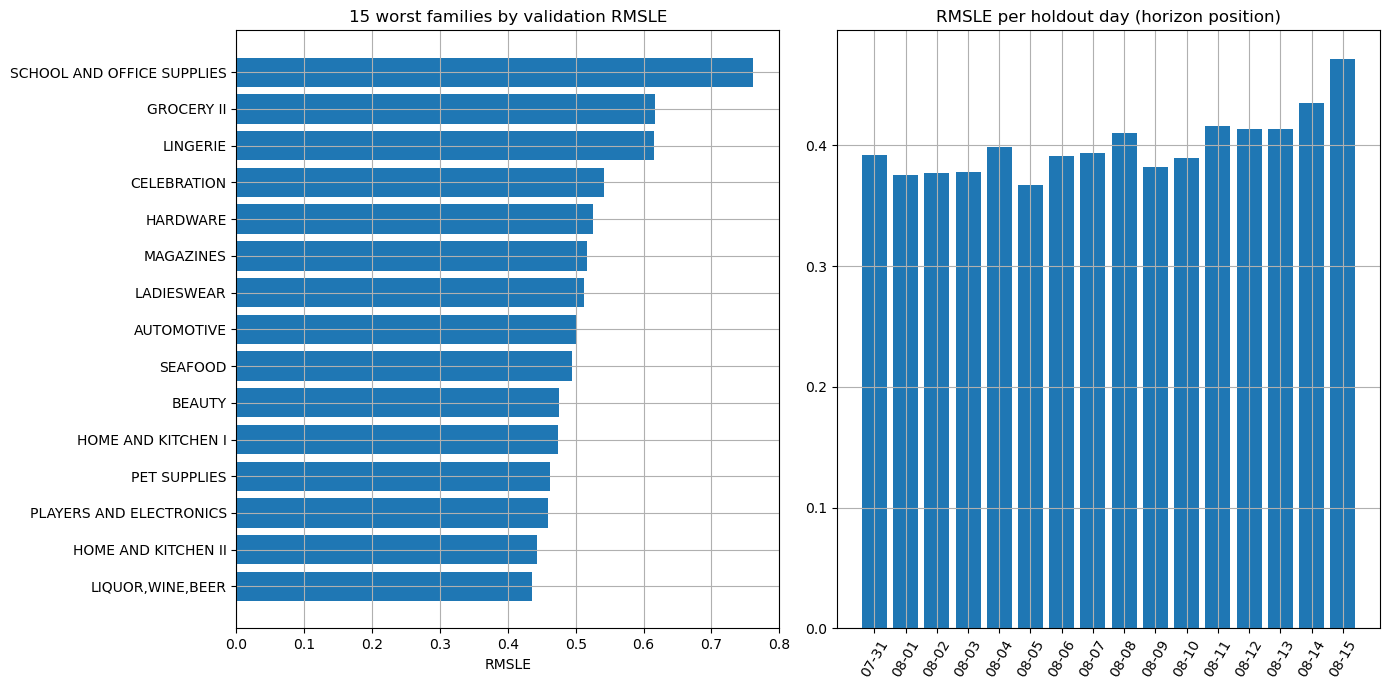

In [7]:
va = val[['date', 'family', 'store_nbr', 'sales']].copy()
va['pred'] = best_pred
va['sq_log_err'] = (np.log1p(va['pred']) - np.log1p(va['sales'])) ** 2

by_family = (va.groupby('family', observed=True)['sq_log_err'].mean() ** 0.5).sort_values()
by_day = (va.groupby('date')['sq_log_err'].mean() ** 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(by_family.index[-15:], by_family.values[-15:])
axes[0].set_title('15 worst families by validation RMSLE')
axes[0].set_xlabel('RMSLE')
axes[1].bar(by_day.index.strftime('%m-%d'), by_day.values)
axes[1].set_title('RMSLE per holdout day (horizon position)')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

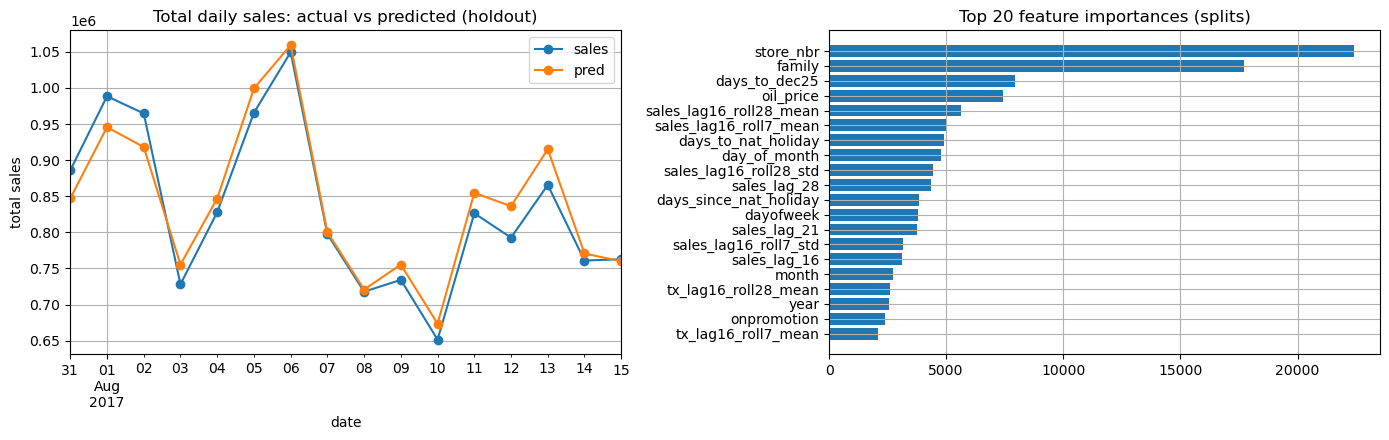

In [8]:
daily_tot = va.groupby('date')[['sales', 'pred']].sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
daily_tot.plot(ax=axes[0], marker='o')
axes[0].set_title('Total daily sales: actual vs predicted (holdout)')
axes[0].set_ylabel('total sales')

imp = (pd.Series(best_model.feature_importances_, index=FEATURES_BASE)
       .sort_values().tail(20))
axes[1].barh(imp.index, imp.values)
axes[1].set_title('Top 20 feature importances (splits)')
plt.tight_layout()
plt.show()

## 6. Rolling-origin stability check

The leaderboard came back **0.08 worse** than validation. Before reacting, check whether the holdout itself is trustworthy: rerun the same configuration on two earlier 16-day windows. If the model score and its gain over the naive baseline are stable across folds, the validation *procedure* is sound and the LB offset is a property of the August test window — what matters for iterating is that experiment **rankings** agree across folds, not the absolute number.

In [9]:
def run_fold(val_start):
    vs = pd.Timestamp(val_start)
    ve = vs + pd.Timedelta(days=15)
    f_trn = train[train['date'] < vs]
    f_val = train[(train['date'] >= vs) & (train['date'] <= ve)]
    y = f_val['sales'].to_numpy()
    model = fit_lgbm(f_trn, f_val)
    return {'fold': f'{vs.date()} -> {ve.date()}',
            'model_rmsle': rmsle(y, predict_sales(model, f_val)),
            'naive_rmsle': rmsle(y, f_val['sales_lag16_roll28_mean'].to_numpy())}

folds = pd.DataFrame([
    run_fold('2017-06-15'),
    run_fold('2017-06-30'),
    {'fold': '2017-07-31 -> 2017-08-15 (primary)', 'model_rmsle': score_full,
     'naive_rmsle': rmsle(y_val, val['sales_lag16_roll28_mean'].to_numpy())},
])
folds['gain_vs_naive'] = folds['naive_rmsle'] - folds['model_rmsle']
folds

,fold,model_rmsle,naive_rmsle,gain_vs_naive
0,2017-06-15 -> 2017-06-30,0.383629,0.501518,0.117890
1,2017-06-30 -> 2017-07-15,0.379081,0.458869,0.079788
2,2017-07-31 -> 2017-08-15 (primary),0.401223,0.550231,0.149008


## 7. The leaderboard gap: August school season

First Kaggle submission: **0.48279** public LB vs **0.4012** validation. Beyond the generic "one step further from training data", the concrete suspect is seasonality that the test window (Aug 16–31) has but the holdout (Jul 31–Aug 15) only starts to show: the **school-shopping ramp** ahead of the September school start in Sierra Ecuador. Below: which families dominate the holdout error, and what SCHOOL AND OFFICE SUPPLIES does each year in Jun–Sep — if it climbs steeply right through the test window, the short lags (≤ 28 days) cannot see that coming, and a *yearly* lag is the targeted fix (§8).

share of total holdout squared log error:
family
SCHOOL AND OFFICE SUPPLIES    10.9%
GROCERY II                     7.2%
LINGERIE                       7.1%
CELEBRATION                    5.5%
HARDWARE                       5.2%
MAGAZINES                      5.0%
LADIESWEAR                     5.0%
AUTOMOTIVE                     4.7%


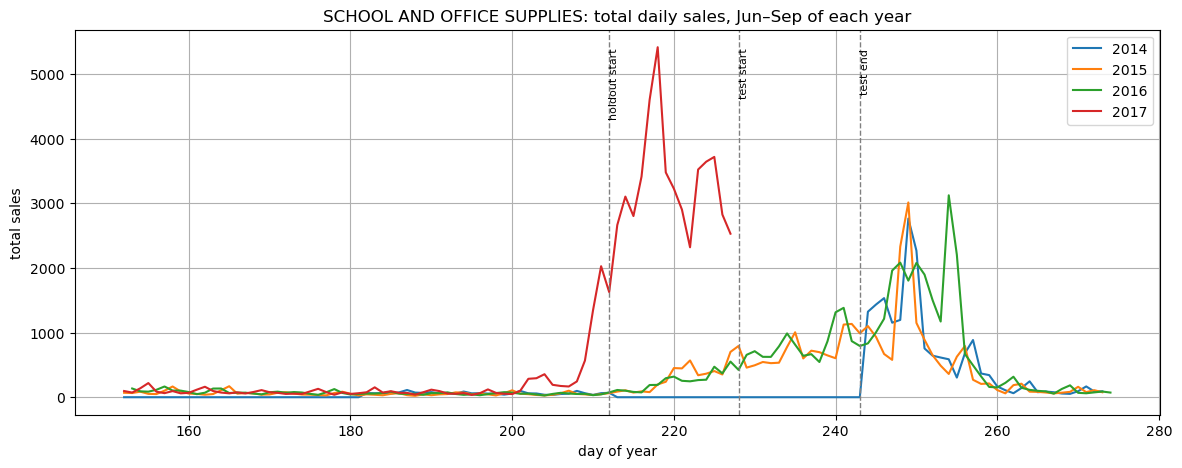

In [10]:
contrib = va.groupby('family', observed=True)['sq_log_err'].sum().sort_values(ascending=False)
print('share of total holdout squared log error:')
print((contrib / contrib.sum()).head(8).map('{:.1%}'.format).to_string())

sch_daily = (train[train['family'] == 'SCHOOL AND OFFICE SUPPLIES']
             .groupby('date')['sales'].sum())
fig, ax = plt.subplots()
for yr in (2014, 2015, 2016, 2017):
    s = sch_daily.loc[f'{yr}-06-01':f'{yr}-09-30']
    ax.plot(s.index.dayofyear, s.values, label=yr)
for x, lbl in ((pd.Timestamp('2017-07-31').dayofyear, 'holdout start'),
               (pd.Timestamp('2017-08-16').dayofyear, 'test start'),
               (pd.Timestamp('2017-08-31').dayofyear, 'test end')):
    ax.axvline(x, linestyle='--', linewidth=1, color='grey')
    ax.text(x, ax.get_ylim()[1] * 0.95, lbl, rotation=90, va='top', fontsize=8)
ax.set_title('SCHOOL AND OFFICE SUPPLIES: total daily sales, Jun–Sep of each year')
ax.set_xlabel('day of year')
ax.set_ylabel('total sales')
ax.legend()
plt.show()

## 8a. Experiment: yearly seasonality features (lag-364)

The short lags (16/21/28) can only extrapolate the recent level — they cannot *see a seasonal ramp coming*. `sales_lag_364` (same weekday, 52 weeks ago) and `sales_lag364_roll7_mean` (the week around the same date last year) tell the model what this series did in late August of previous years. Both were added in preprocessing with shifts ≥ 16 days, so they stay leak-free over the whole horizon.

One caveat for judging this experiment: the primary holdout (Jul 31 – Aug 15) contains only the *start* of the school ramp, so it structurally cannot reward a feature whose payoff is late August — §8b re-judges on the real season.

In [11]:
features_yearly = FEATURES_BASE + YEARLY
model_yearly = fit_lgbm(trn, val, features_yearly)
pred_yearly = predict_sales(model_yearly, val, features_yearly)
score_yearly = rmsle(y_val, pred_yearly)
exp_log.append({'experiment': 'LightGBM, full history + yearly lags',
                'train_rows': len(trn), 'val_rmsle': score_yearly})
print(f'best_iteration: {model_yearly.best_iteration_}   '
      f'val RMSLE: {score_yearly:.5f}  (base model: {score_full:.5f})')

# did the school family specifically improve?
m = (val['family'] == 'SCHOOL AND OFFICE SUPPLIES').to_numpy()
print('SCHOOL AND OFFICE SUPPLIES RMSLE: '
      f'base {rmsle(y_val[m], best_pred[m]):.4f} -> yearly {rmsle(y_val[m], pred_yearly[m]):.4f}')

rank = pd.Series(model_yearly.feature_importances_, index=features_yearly).rank(ascending=False)
print('importance rank of yearly features:', {c: int(rank[c]) for c in YEARLY},
      f'(of {len(features_yearly)})')

best_iteration: 1164   val RMSLE: 0.40263  (base model: 0.40122)
SCHOOL AND OFFICE SUPPLIES RMSLE: base 0.7620 -> yearly 0.7977
importance rank of yearly features: {'sales_lag_364': 13, 'sales_lag364_roll7_mean': 6} (of 33)


## 8b. Re-judging the yearly lags on the real season: Aug 16–31, 2016

The fair test for a late-August feature is a late-August fold: train on everything before 2016-08-16, validate on **2016-08-16 → 2016-08-31** — exactly the competition window, one year earlier. The school ramp is *inside* this fold, so if the yearly lags genuinely help where it matters, it shows here even though the primary holdout couldn't see it.

In [12]:
vs, ve = pd.Timestamp('2016-08-16'), pd.Timestamp('2016-08-31')
f_trn = train[train['date'] < vs]
f_val = train[(train['date'] >= vs) & (train['date'] <= ve)]
y16 = f_val['sales'].to_numpy()
m16 = (f_val['family'] == 'SCHOOL AND OFFICE SUPPLIES').to_numpy()

m16_base = fit_lgbm(f_trn, f_val)
p16_base = predict_sales(m16_base, f_val)
m16_yearly = fit_lgbm(f_trn, f_val, features_yearly)
p16_yearly = predict_sales(m16_yearly, f_val, features_yearly)

s16_base, s16_yearly = rmsle(y16, p16_base), rmsle(y16, p16_yearly)
exp_log.append({'experiment': 'LightGBM, base [Aug-2016 fold]',
                'train_rows': len(f_trn), 'val_rmsle': s16_base})
exp_log.append({'experiment': 'LightGBM, + yearly lags [Aug-2016 fold]',
                'train_rows': len(f_trn), 'val_rmsle': s16_yearly})

print(f'Aug-2016 fold:  base {s16_base:.5f}  ->  yearly {s16_yearly:.5f}')
print('SCHOOL AND OFFICE SUPPLIES: '
      f'base {rmsle(y16[m16], p16_base[m16]):.4f} -> yearly {rmsle(y16[m16], p16_yearly[m16]):.4f}')

keep_yearly = s16_yearly < s16_base - 0.001
print(f'-> keep yearly lags: {keep_yearly}')

Aug-2016 fold:  base 0.76526  ->  yearly 0.73106
SCHOOL AND OFFICE SUPPLIES: base 0.6332 -> yearly 0.6277
-> keep yearly lags: True


## 8c. Experiment: promotion intensity features

`onpromotion` is **known in advance** (test.csv ships with it), so unlike sales lags these windows may end at the current day — no leak. The EDA flagged promotions as much more prevalent in the test window (44% non-zero vs 20% in train), so the model should know not just "is this item on promo today" (already a feature) but "how promo-heavy have the last 7/28 days been" — sustained campaigns vs one-day specials behave differently.

In [13]:
features_promo = FEATURES_BASE + PROMO
model_promo = fit_lgbm(trn, val, features_promo)
pred_promo = predict_sales(model_promo, val, features_promo)
score_promo = rmsle(y_val, pred_promo)
exp_log.append({'experiment': 'LightGBM, full history + promo intensity',
                'train_rows': len(trn), 'val_rmsle': score_promo})
print(f'best_iteration: {model_promo.best_iteration_}   '
      f'val RMSLE: {score_promo:.5f}  (base model: {score_full:.5f})')

keep_promo = score_promo < score_full - 0.001
print(f'-> keep promo features: {keep_promo}')

best_iteration: 1085   val RMSLE: 0.39856  (base model: 0.40122)
-> keep promo features: True


## 8d. Late-August error analysis (submission-2 config on the Aug-2016 fold)

Submission 2 confirmed the Aug-2016 fold tracks the leaderboard. So the question "what should we improve next?" should also be asked **on that fold**, not on the primary holdout: fit the yearly+promo configuration there and break the remaining error down by family and by horizon day.

Aug-2016 fold, yearly+promo: 0.74207  (base 0.76526, yearly 0.73106)

share of Aug-2016 fold squared log error (final config):
family
BEVERAGES           8.5%
GROCERY I           8.3%
PRODUCE             6.7%
DAIRY               5.7%
CLEANING            5.5%
BREAD/BAKERY        5.4%
LIQUOR,WINE,BEER    4.1%
DELI                3.8%


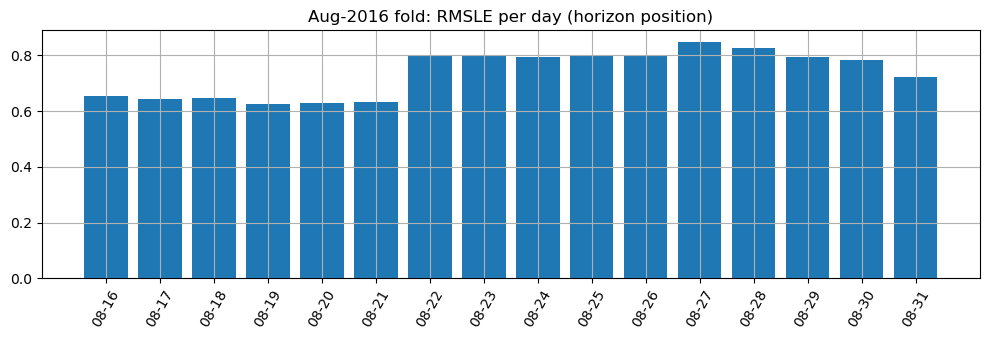

In [14]:
features_yp = FEATURES_BASE + YEARLY + PROMO   # current best config (submission #2)
model_yp16 = fit_lgbm(f_trn, f_val, features_yp)
p16_yp = predict_sales(model_yp16, f_val, features_yp)
print(f'Aug-2016 fold, yearly+promo: {rmsle(y16, p16_yp):.5f}  '
      f'(base {s16_base:.5f}, yearly {s16_yearly:.5f})')

fa = f_val[['date', 'family']].copy()
fa['sq_log_err'] = (np.log1p(p16_yp) - np.log1p(y16)) ** 2
contrib16 = fa.groupby('family', observed=True)['sq_log_err'].sum().sort_values(ascending=False)
print('\nshare of Aug-2016 fold squared log error (final config):')
print((contrib16 / contrib16.sum()).head(8).map('{:.1%}'.format).to_string())

by_day16 = fa.groupby('date')['sq_log_err'].mean() ** 0.5
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(by_day16.index.strftime('%m-%d'), by_day16.values)
ax.set_title('Aug-2016 fold: RMSLE per day (horizon position)')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## 8e. Experiment: weekday & intermittency aggregates

Two cheap aggregates that target what §8d shows the model still gets wrong:

- `sales_dow4_mean` — mean of the same weekday over the last 4 observable weeks (lags 21/28/35/42): a less noisy version of the single lag-21 value, aimed at the dominant weekly cycle;
- `sales_zero_rate_28` — share of zero-sales days in the last 28 observable days: tells the model *how intermittent* a series currently is, smoother than the binary `is_dead_series`.

Judged on the primary holdout (these are not season-specific).

In [15]:
features_aggs = FEATURES_BASE + AGGS
model_aggs = fit_lgbm(trn, val, features_aggs)
pred_aggs = predict_sales(model_aggs, val, features_aggs)
score_aggs = rmsle(y_val, pred_aggs)
exp_log.append({'experiment': 'LightGBM, full history + weekday/intermittency aggs',
                'train_rows': len(trn), 'val_rmsle': score_aggs})
print(f'best_iteration: {model_aggs.best_iteration_}   '
      f'val RMSLE: {score_aggs:.5f}  (base model: {score_full:.5f})')

keep_aggs = score_aggs < score_full - 0.001
print(f'-> keep aggregate features: {keep_aggs}')

best_iteration: 933   val RMSLE: 0.40292  (base model: 0.40122)
-> keep aggregate features: False


## 8f. Configuration choice

Greedy keep-rules, each judged on the fold that can actually measure it: **yearly lags** on the Aug-2016 seasonal fold (the primary holdout structurally under-credits late-August payoff), **promo** and **aggregate** features on the primary holdout. A kept feature group must win by > 0.001 RMSLE — anything smaller is fold noise (§6 showed fold-to-fold spread of ~0.02). The chosen combination always gets a confirmation fit, which also provides the early-stopped tree count for the final retrain.

In [16]:
extras = ((YEARLY if keep_yearly else []) + (PROMO if keep_promo else [])
          + (AGGS if keep_aggs else []))
best_features = FEATURES_BASE + extras
cutoff = '2013-01-01'   # §4: full history won
best_name = 'full history' + (' + ' + ' + '.join(
    g for g, k in [('yearly', keep_yearly), ('promo', keep_promo), ('aggs', keep_aggs)] if k)
    if extras else ' (base)')

# confirmation fit of the chosen combination
best_model = fit_lgbm(trn, val, best_features)
best_pred = predict_sales(best_model, val, best_features)
exp_log.append({'experiment': f'LightGBM, {best_name} (final config)',
                'train_rows': len(trn), 'val_rmsle': rmsle(y_val, best_pred)})

print(f'final config: {best_name}, {len(best_features)} features, '
      f'primary-holdout RMSLE {rmsle(y_val, best_pred):.5f}')

final config: full history + yearly + promo, 35 features, primary-holdout RMSLE 0.39847


## 9. Experiment log

In [17]:
log_df = pd.DataFrame(exp_log).sort_values('val_rmsle').reset_index(drop=True)
log_df

,experiment,train_rows,val_rmsle
0,"LightGBM, full history + yearly + promo (final...",2686530,0.398475
1,"LightGBM, full history + promo intensity",2686530,0.398557
2,"LightGBM, full history (2013+)",2686530,0.401223
3,"LightGBM, 2015+ history",1619772,0.401458
4,"LightGBM, full history + yearly lags",2686530,0.402629
5,"LightGBM, full history + weekday/intermittency...",2686530,0.402919
6,rolling-28 mean (lag-16),0,0.550231
7,rolling-28 mean (lag-16) + dead rule,0,0.550231
8,naive lag-21 (same weekday),0,0.632989
9,naive lag-21 (same weekday) + dead rule,0,0.632989


## 10. Final retrain & submission

Retrain the winning configuration (feature set + history cutoff chosen above) on **all** train rows — the held-out last 16 days are the most relevant data we have for mid-August. Tree count = best early-stopped iteration + 10% (slightly more data supports slightly more trees). Predictions: `expm1` → clip at 0 → dead-series rule.

In [18]:
final_train = train[train['date'] >= cutoff]
n_trees = int(best_model.best_iteration_ * 1.1)

final_model = lgb.LGBMRegressor(**{**PARAMS, 'n_estimators': n_trees})
final_model.fit(final_train[best_features], final_train[TARGET])

test_pred = predict_sales(final_model, test, best_features)
submission = test[['id']].assign(sales=test_pred).sort_values('id')
submission.to_csv('submission.csv', index=False)

print(f'final model: {best_name}, {n_trees} trees, {len(final_train):,} rows, '
      f'{len(best_features)} features')
print(f'submission.csv: {submission.shape}, sales range '
      f'{submission["sales"].min():.2f} -> {submission["sales"].max():.2f}')
submission.head()

final model: full history + yearly + promo, 1309 trees, 2,715,042 rows, 35 features
submission.csv: (28512, 2), sales range 0.00 -> 14521.62


,id,sales
1688,3000888,4.382893
3392,3000889,0.000000
5096,3000890,5.860295
6800,3000891,2487.717276
8504,3000892,0.226374


## Submission log & next steps

| # | configuration | local validation | public LB |
|---|---|---|---|
| 1 | base LightGBM, 31 features | 0.4012 (holdout) | 0.48279 |
| 2 | + yearly lags + promo, 35 features | 0.3985 (holdout) | 0.44810 |
| 3 | ensemble 80% pure + 20% hybrid (`04_hybrid_ensemble.ipynb`) | 0.3940 (holdout) | 0.42844 |
| 4 | TFT v1, raw sequences + covariates (`05_tft_v1.ipynb`) | 0.4810 (holdout) | 0.42820 |
| 5 | 50/50 log-blend of #3 and #4 (`submission_blend.csv`) | — | 0.40775 |
| 6 | TFT v2: + engineered lags as exog, capped (`06_tft_v2.ipynb`) | — | 0.40810 |
| 7 | 50/50 log-blend of #3 and #6 (`submission_blend2.csv`) | — | **0.39962** |

**Three lessons, each confirmed on the leaderboard:**

1. *Validation-window placement* (submissions 2, 4): a holdout positioned before a seasonal event understates models/features whose value sits in that event. TFT v1 scored 0.481 on the holdout yet 0.428 on the real (late-August) test.
2. *Diversity drives blends* (submission 5): two ~0.428 models that err differently (mean |log-diff| 0.15) averaged to 0.408.
3. *Feature engineering lifts the neural model too* (submission 6): feeding the engineered lags as known-future exog took the TFT from 0.428 → 0.408 — closing almost the entire gap to the GBDT family, no year-long input window needed. The predicted diversity-loss risk did **not** bite: v2 and the hybrid still differ enough (mean |log-diff| 0.13) that the blend improved again to **0.39962**, the best result and the first sub-0.40.

A per-series cap (2× historical max) was required on v2 — the net over-extrapolated the school ramp to 22k–78k units on 8 rows; trees cannot make this class of error, neural nets can.

If continuing: tune the blend weight (currently a flat 0.5); a 3-way blend of hybrid + v1 + v2; light LightGBM hyperparameter tuning. Diminishing returns — 0.483 → 0.400 over the session is a strong stopping point.